# Лабораторна робота №3 — Порівняння оптимізаторів **SGD**, **RMSProp** і **Adam** на прикладі простої CNN

**Студентка:** Olena Mykhailovska  
**Група:** CS-31  
**STUDENT_NO:** 12

# 1. Імпорт бібліотек

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
keras.utils.set_random_seed(42)

# 2. Завантаження датасету Fashion-MNIST

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 3. Нормалізація даних

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 4. Додавання каналу

In [4]:
x_train = x_train[..., None]
x_test = x_test[..., None]

# 5. Перевірка форми даних

In [5]:
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

x_train: (60000, 28, 28, 1)
x_test : (10000, 28, 28, 1)
y_train: (60000,)
y_test : (10000,)


# 6. Візуалізація прикладів зображень

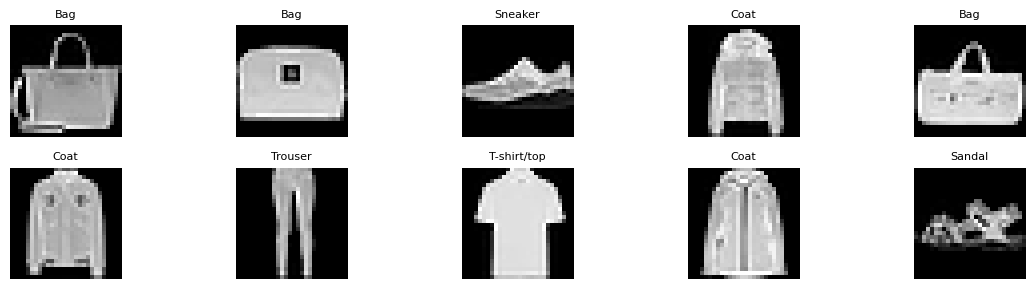

In [6]:
idx = np.random.choice(len(x_train), 10, replace=False)

plt.figure(figsize=(12,3))

for i,j in enumerate(idx,start=1):
    plt.subplot(2,5,i)
    plt.imshow(x_train[j].squeeze(), cmap="gray")
    plt.title(class_names[y_train[j]], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 7. CNN з Dropout

In [7]:
def build_cnn():
    
    model = keras.Sequential([
        
        keras.Input(shape=(28,28,1)),
        
        layers.Conv2D(32,(3,3),activation="relu",padding="same"),
        layers.MaxPooling2D((2,2)),
        
        layers.Conv2D(64,(3,3),activation="relu",padding="same"),
        layers.MaxPooling2D((2,2)),
        
        layers.Flatten(),
        
        layers.Dense(128,activation="relu"),
        
        layers.Dropout(0.3),   # новий шар
        
        layers.Dense(10,activation="softmax")
        
    ],name="cnn_dropout_model")
    
    return model

# 8. Callback функції

In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

# 9. Функція навчання моделі

In [9]:
def train_with_optimizer(optimizer, name, epochs=15, batch_size=128):
    
    model = build_cnn()
    
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    start = time.time()
    
    history = model.fit(
        x_train,
        y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    elapsed = time.time() - start
    
    test_loss, test_acc = model.evaluate(x_test,y_test,verbose=0)
    
    return {
        "name":name,
        "history":history.history,
        "test_loss":float(test_loss),
        "test_acc":float(test_acc),
        "train_time":float(elapsed),
        "model":model
    }

# 10. Експеримент з learning rate

In [10]:
sgd_1 = train_with_optimizer(
    keras.optimizers.SGD(learning_rate=0.1),
    "SGD lr=0.1"
)

sgd_2 = train_with_optimizer(
    keras.optimizers.SGD(learning_rate=0.01),
    "SGD lr=0.01"
)

sgd_3 = train_with_optimizer(
    keras.optimizers.SGD(learning_rate=0.001),
    "SGD lr=0.001"
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6962 - loss: 0.8051 - val_accuracy: 0.8202 - val_loss: 0.4910 - learning_rate: 0.1000
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8205 - loss: 0.4857 - val_accuracy: 0.8520 - val_loss: 0.4028 - learning_rate: 0.1000
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8514 - loss: 0.4120 - val_accuracy: 0.8648 - val_loss: 0.3610 - learning_rate: 0.1000
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8651 - loss: 0.3696 - val_accuracy: 0.8793 - val_loss: 0.3327 - learning_rate: 0.1000
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8762 - loss: 0.3418 - val_accuracy: 0.8847 - val_loss: 0.3137 - learning_rate: 0.1000
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8832 - loss: 0.3220 - val_accuracy: 0.8908 - val_loss: 0.2952 - learning_rate: 0.1000
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8868 - loss: 

# 11. SGD + momentum

In [11]:
sgd_momentum = train_with_optimizer(
    keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "SGD + momentum"
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7030 - loss: 0.7998 - val_accuracy: 0.8170 - val_loss: 0.4911 - learning_rate: 0.0100
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8225 - loss: 0.4828 - val_accuracy: 0.8498 - val_loss: 0.4044 - learning_rate: 0.0100
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8558 - loss: 0.4024 - val_accuracy: 0.8698 - val_loss: 0.3625 - learning_rate: 0.0050


# 12. RMSProp

In [12]:
rms_1 = train_with_optimizer(
    keras.optimizers.RMSprop(learning_rate=0.001),
    "RMSProp 0.001"
)

rms_2 = train_with_optimizer(
    keras.optimizers.RMSprop(learning_rate=0.0005),
    "RMSProp 0.0005"
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7971 - loss: 0.5721 - val_accuracy: 0.8748 - val_loss: 0.3450 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8779 - loss: 0.3426 - val_accuracy: 0.8915 - val_loss: 0.2941 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9015 - loss: 0.2743 - val_accuracy: 0.9047 - val_loss: 0.2613 - learning_rate: 5.0000e-04
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7655 - loss: 0.6514 - val_accuracy: 0.8548 - val_loss: 0.3974 - learning_rate: 5.0000e-04
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8593 - loss: 0.3916 - val_accuracy: 0.8813 - val_loss: 0.3263 - learning_rate: 5.0000e-04
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8847 - loss: 0.3242 - val_accuracy: 0.8903 - val_loss: 0.2998 - learning_rate: 2.5000e-04


# 13. Adam

In [13]:
adam_1 = train_with_optimizer(
    keras.optimizers.Adam(learning_rate=0.001),
    "Adam 0.001"
)

adam_2 = train_with_optimizer(
    keras.optimizers.Adam(learning_rate=0.0005),
    "Adam 0.0005"
)

adam_3 = train_with_optimizer(
    keras.optimizers.Adam(learning_rate=0.0001),
    "Adam 0.0001"
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8015 - loss: 0.5525 - val_accuracy: 0.8658 - val_loss: 0.3566 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8776 - loss: 0.3433 - val_accuracy: 0.8938 - val_loss: 0.2885 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8970 - loss: 0.2855 - val_accuracy: 0.8987 - val_loss: 0.2721 - learning_rate: 5.0000e-04
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7762 - loss: 0.6254 - val_accuracy: 0.8568 - val_loss: 0.3961 - learning_rate: 5.0000e-04
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8620 - loss: 0.3886 - val_accuracy: 0.8840 - val_loss: 0.3217 - learning_rate: 5.0000e-04
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8815 - loss: 0.3310 - val_accuracy: 0.8902 - val_loss: 0.3002 - learning_rate: 2.5000e-04
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accu

# 14. Об'єднання результатів

In [14]:
results = [
    sgd_1,sgd_2,sgd_3,
    sgd_momentum,
    rms_1,rms_2,
    adam_1,adam_2,adam_3
]

# 15. Графік accuracy

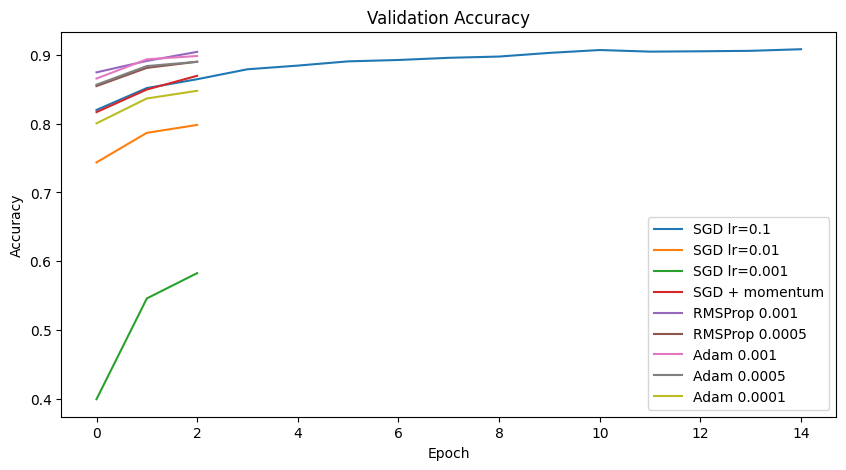

In [15]:
plt.figure(figsize=(10,5))

for res in results:
    plt.plot(res["history"]["val_accuracy"], label=res["name"])

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 16. Порівняння test accuracy

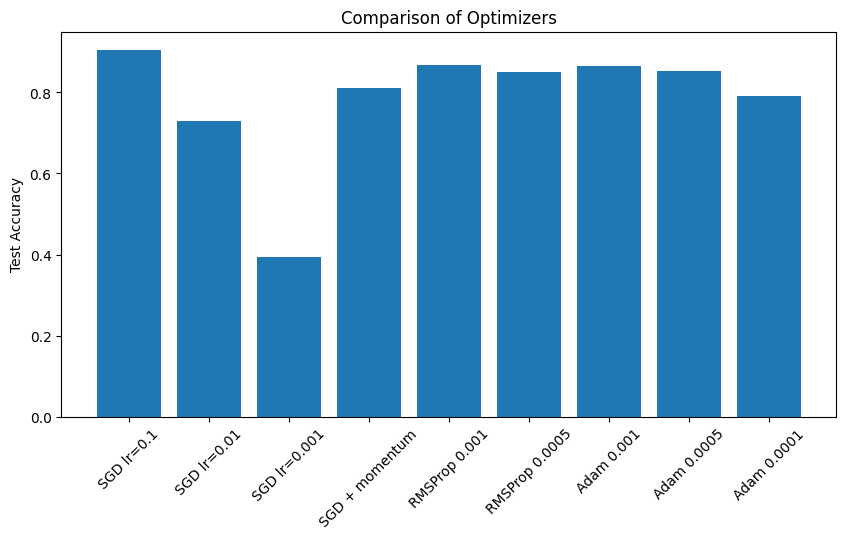

In [16]:
names=[r["name"] for r in results]
acc=[r["test_acc"] for r in results]

plt.figure(figsize=(10,5))
plt.bar(names,acc)

plt.xticks(rotation=45)
plt.ylabel("Test Accuracy")
plt.title("Comparison of Optimizers")

plt.show()

# 17. Найкращий оптимізатор

In [17]:
best=max(results,key=lambda r:r["test_acc"])

print("Best optimizer:",best["name"])
print("Test accuracy:",best["test_acc"])

Best optimizer: SGD lr=0.1
Test accuracy: 0.9045000076293945


# 18. Classification Report

In [18]:
best_model=best["model"]

y_prob=best_model.predict(x_test,verbose=0)
y_pred=np.argmax(y_prob,axis=1)

print(classification_report(y_test,y_pred,target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.90      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.88      0.80      0.84      1000
       Dress       0.88      0.93      0.91      1000
        Coat       0.81      0.87      0.84      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.77      0.67      0.72      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



# 19. Confusion Matrix

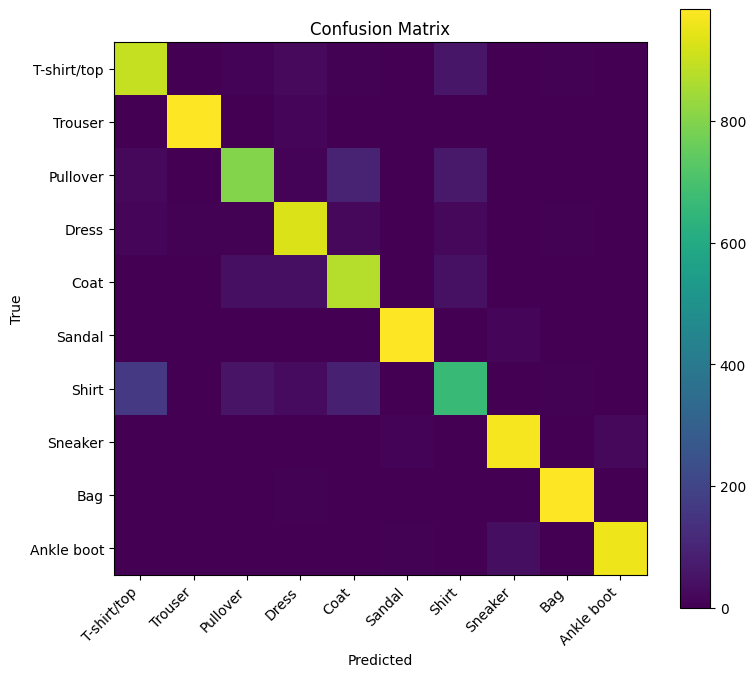

In [19]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,7))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(range(10),class_names,rotation=45,ha="right")
plt.yticks(range(10),class_names)

plt.colorbar()
plt.tight_layout()
plt.show()

# 20. Висновок

У цьому експерименті ми дослідили вплив learning rate, momentum, Dropout та callbacks на навчання CNN. Було проведено експерименти з різними оптимізаторами: SGD, SGD з momentum, RMSProp та Adam.

Результати показали, що learning rate суттєво впливає на якість навчання. Занадто малий learning rate призводить до дуже повільної збіжності моделі.

Найкращий результат у нашому експерименті показав SGD з learning rate = 0.1 з точністю близько 90% на test set.

Також використання Dropout допомогло зменшити перенавчання, а callbacks дозволили автоматично регулювати процес навчання.
